# Dalhousie Argo Floats: Raw Eco and Tridente Data

Code to read and plot ascent profile data for PROVOR V floats equipped with SeaBird Scientific EcoPuck or RBR Tridente sensors measuring chlorophyll and backscatter.

In [31]:
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


## Functions

Define functions to read eco and tridente files, as well as technical files to get other relevant metadata. 

In [70]:

def read_eco(fn):
    '''
    Function to read SBS Eco sensor files from PROVOR V floats.

    Args:
        fn: file name

    Returns:
        pandas.DataFrame containing the ascent data in `fn`
    '''

    data_dict = {
        'TIME':[],
        'PRES':[],
        'FLUORESCENCE_CHLA':[],
        'BBP_COUNTS':[],
        'SAMPLE':[],
        'MODE':[],
    }

    with open(fn, 'r') as fid:
        for line in fid:
            print(line.strip())
            if line[0] == '#':
                continue
            elif line[0] == '[':
                sample = line.strip('[]\n')
                mode = ''
            elif line[0] == '(':
                mode = line.strip('()\n')
            else:
                line_data = line.split(',')
                data_dict['TIME'].append(pd.Timestamp(line_data[0]))
                data_dict['PRES'].append(float(line_data[1]))
                data_dict['SAMPLE'].append(sample)
                data_dict['MODE'].append(mode)

                data_dict['FLUORESCENCE_CHLA'].append(float(line_data[2]))
                data_dict['BBP_COUNTS'].append(float(line_data[3]))

    return pd.DataFrame(data_dict)

def read_tridente(fn, channels):
    '''
    Function to read RBR Tridente sensor files from PROVOR V floats.

    Args:
        fn: file name

    Returns:
        pandas.DataFrame containing the ascent data in `fn`
    '''

    data_dict = {
        'TIME':[],
        'PRES':[],
        f'{channels[0]}_MEAN':[],
        f'{channels[1]}_MEAN':[],
        f'{channels[2]}_MEAN':[],
        f'{channels[0]}_MED':[],
        f'{channels[1]}_MED':[],
        f'{channels[2]}_MED':[],
        f'{channels[0]}_STDDEV':[],
        f'{channels[1]}_STDDEV':[],
        f'{channels[2]}_STDDEV':[],
        'SAMPLE':[],
        'MODE':[]
    }

    mode = ''
    with open(fn, 'r') as fid:
        for line in fid:
            print(line.strip())
            if line[0] == '#':
                continue
            elif line[0] == '[':
                sample = line.strip('[]\n')
                mode = ''
            elif line[0] == '(':
                mode = line.strip('()\n')
            else:
                line_data = line.split(',')
                data_dict['TIME'].append(pd.Timestamp(line_data[0]))
                data_dict['PRES'].append(float(line_data[1]))
                data_dict['SAMPLE'].append(sample)
                data_dict['MODE'].append(mode)

                for i, c in enumerate(channels):
                    for j, s in enumerate(['MEAN', 'MED', 'STDDEV']):
                        data_dict[f'{c}_{s}'].append(float(line_data[2+i+3*j]))

    return pd.DataFrame(data_dict)

def read_tech(fn):
    '''
    Function to read technical files from PROVOR V floats.

    Args:
        fn: file name

    Returns:
        dict with all data fields from `fn`
    '''

## Resolution Changes

Vertical resolution for Eco sensors was changed on August 5, check before and after resolution.

In [71]:
eco_files = list(Path('../data/provor/300125062423120/').glob('*eco*.csv'))

df1 = read_eco(eco_files[0])
df2 = read_eco(eco_files[-1])

#08#
[PARK]
2026-07-08 21:36:45,1974.80,50,108
2026-07-08 22:36:51,1983.50,50,112
2026-07-08 23:36:54,1986.80,50,109
2026-07-09 00:36:57,1985.10,50,106
2026-07-09 01:37:00,1985.80,51,107
2026-07-09 02:37:03,1983.60,50,108
2026-07-09 03:37:06,1988.70,50,109
2026-07-09 04:37:09,1982.00,50,108
2026-07-09 05:37:12,1989.50,50,106
2026-07-09 06:37:15,1985.30,50,106
2026-07-09 07:37:18,1992.10,50,107
2026-07-09 08:37:21,1985.90,50,107
2026-07-09 09:37:24,1989.30,50,115
2026-07-09 10:37:27,1987.30,50,112
2026-07-09 11:37:30,1987.90,49,105
2026-07-09 12:37:33,1987.20,50,108
2026-07-09 13:37:36,1987.10,50,106
2026-07-09 14:37:39,1987.20,50,108
2026-07-09 15:37:42,1988.90,50,107
2026-07-09 16:37:45,1987.80,50,114
2026-07-09 17:37:48,1989.30,50,108
2026-07-09 18:37:51,1989.40,50,114
2026-07-09 19:37:54,1989.70,49,106
2026-07-09 20:37:57,1989.60,49,107
2026-07-09 21:38:00,1987.50,50,108
2026-07-09 22:38:00,1988.10,50,112
2026-07-09 23:38:03,1989.30,49,107
2026-07-10 00:38:05,1987.80,50,107
2026-07-

C:\Users\GordonC\AppData\Local\Temp\1\ipykernel_28076\1345783700.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['RESOLUTION'] = data.PRES.diff()


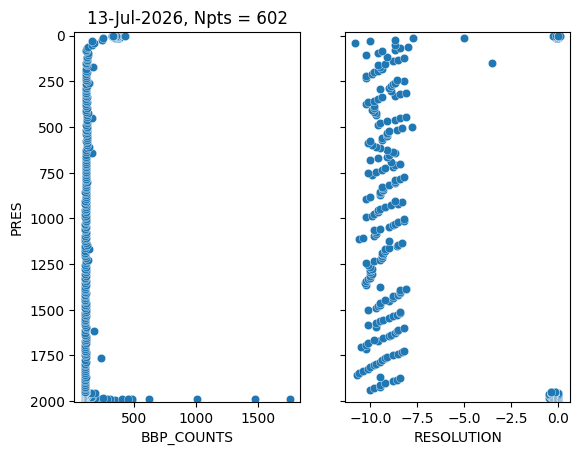

C:\Users\GordonC\AppData\Local\Temp\1\ipykernel_28076\1345783700.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['RESOLUTION'] = data.PRES.diff()


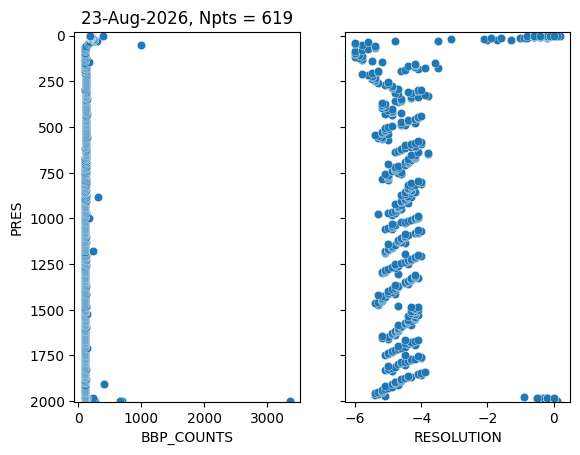

In [109]:
for data in [df1, df2]:
    fig, axes = plt.subplots(1, 2, sharey=True)
    data = data.loc[data['SAMPLE'] == 'ASCENT']
    data['RESOLUTION'] = data.PRES.diff()
    sns.scatterplot(data=data, x='BBP_COUNTS', y='PRES', linewidth=0.25, ax=axes[0])
    sns.scatterplot(data=data, x='RESOLUTION', y='PRES', linewidth=0.25, ax=axes[1])
    axes[0].set_ylim((2003, -20))
    axes[0].set_title(f'{data["TIME"].iloc[0].strftime("%d-%b-%Y")}, Npts = {data.shape[0]}')
    plt.show()

In [85]:
df2.loc[(df2.SAMPLE == 'ASCENT') & (df2.PRES > 1980)]

,TIME,PRES,FLUORESCENCE_CHLA,BBP_COUNTS,SAMPLE,MODE
104,2026-08-23 23:45:36,1998.4,49.0,110.0,ASCENT,RW
105,2026-08-23 23:45:38,1998.4,49.0,115.0,ASCENT,RW
106,2026-08-23 23:45:41,1998.4,50.0,118.0,ASCENT,RW
107,2026-08-23 23:45:43,1998.3,49.0,119.0,ASCENT,RW
108,2026-08-23 23:45:45,1998.4,49.0,120.0,ASCENT,RW
...,...,...,...,...,...,...
258,2026-08-23 23:51:07,1980.9,49.0,112.0,ASCENT,RW
259,2026-08-23 23:51:09,1980.7,50.0,108.0,ASCENT,RW
260,2026-08-23 23:51:11,1980.5,50.0,117.0,ASCENT,RW
261,2026-08-23 23:51:13,1980.3,48.0,109.0,ASCENT,RW


## Tridente Data

Take a look at raw tridente data.

In [94]:
tridente_files = list(Path('../data/provor/300125063415280/').glob('*tridente*.csv'))

df = read_tridente(tridente_files[-1], channels=['BBP700', 'CHLA', 'FDOM'])
df

#45#
[PARK]
2026-08-11 02:11:21,1971.50,0.000115,0.030492,2.376866,0.000115,0.028625,2.374606,0.000001,0.011285,0.018889
2026-08-11 14:11:24,1989.40,0.000109,0.026688,2.378038,0.000109,0.027239,2.380144,0.000000,0.007004,0.020613
2026-08-12 02:11:25,1992.20,0.000109,0.028247,2.375124,0.000109,0.028234,2.375113,0.000000,0.010074,0.018190
2026-08-12 14:11:23,1993.00,0.000109,0.027395,2.381352,0.000110,0.025734,2.380030,0.000001,0.007932,0.022953
2026-08-13 02:11:25,1994.20,0.000141,0.028268,2.377317,0.000142,0.027843,2.380878,0.000003,0.009440,0.020438
2026-08-13 14:11:23,1994.70,0.000109,0.025973,2.375557,0.000109,0.026713,2.375182,0.000001,0.009279,0.019823
2026-08-14 02:11:26,1996.50,0.000112,0.028110,2.384448,0.000112,0.026432,2.384724,0.000001,0.010426,0.017079
2026-08-14 14:11:28,1994.70,0.000110,0.028764,2.378592,0.000110,0.028423,2.373440,0.000000,0.009484,0.015514
2026-08-15 02:11:31,1992.40,0.000109,0.031365,2.383436,0.000109,0.030229,2.386859,0.000000,0.009883,0.019540
2026-08

,TIME,PRES,BBP700_MEAN,CHLA_MEAN,FDOM_MEAN,BBP700_MED,CHLA_MED,FDOM_MED,BBP700_STDDEV,CHLA_STDDEV,FDOM_STDDEV,SAMPLE,MODE
0,2026-08-11 02:11:21,1971.5,0.000115,0.030492,2.376866,0.000115,0.028625,2.374606,0.000001,0.011285,0.018889,PARK,
1,2026-08-11 14:11:24,1989.4,0.000109,0.026688,2.378038,0.000109,0.027239,2.380144,0.000000,0.007004,0.020613,PARK,
2,2026-08-12 02:11:25,1992.2,0.000109,0.028247,2.375124,0.000109,0.028234,2.375113,0.000000,0.010074,0.018190,PARK,
3,2026-08-12 14:11:23,1993.0,0.000109,0.027395,2.381352,0.000110,0.025734,2.380030,0.000001,0.007932,0.022953,PARK,
4,2026-08-13 02:11:25,1994.2,0.000141,0.028268,2.377317,0.000142,0.027843,2.380878,0.000003,0.009440,0.020438,PARK,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,2026-08-16 11:49:32,0.3,0.000249,0.563549,2.024104,0.000246,0.560609,2.043263,0.000009,0.035454,0.135665,ASCENT,RW
826,2026-08-16 11:50:32,0.4,0.000265,0.580800,1.927708,0.000262,0.573573,1.936388,0.000009,0.030001,0.132487,ASCENT,RW
827,2026-08-16 11:51:32,0.3,0.000259,0.580226,2.003362,0.000258,0.577361,2.015163,0.000007,0.046578,0.148338,ASCENT,RW
828,2026-08-16 11:52:32,0.4,0.000265,0.548361,1.965769,0.000259,0.546002,1.982057,0.000027,0.030080,0.133209,ASCENT,RW


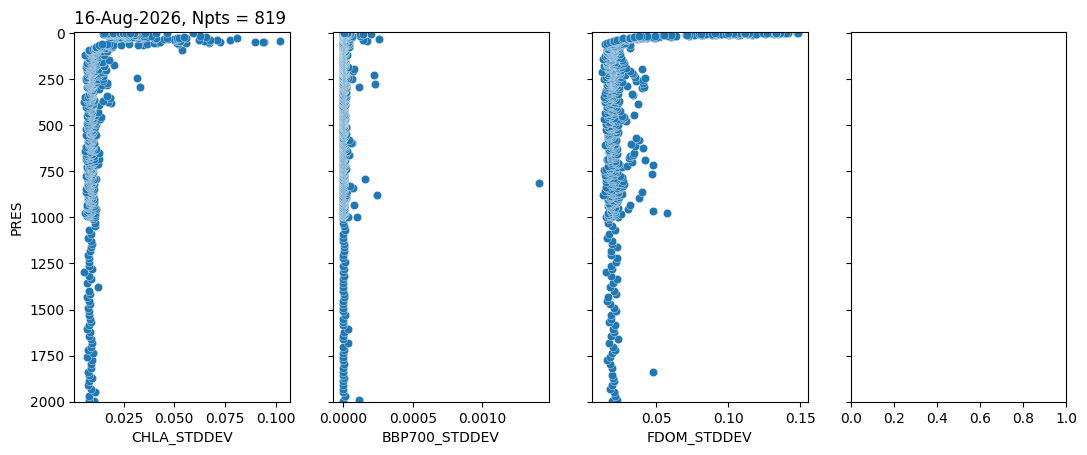

In [ ]:
df = df.loc[df.SAMPLE == 'ASCENT']

for s in ['MEAN', 'MED', 'STDDEV']:
    fig, axes = plt.subplots(1, 3, sharey=True)
    for ax, v in zip(axes, ['CHLA', 'BBP700', 'FDOM']):
        sns.scatterplot(data=df, x=f'{v}_{s}', y='PRES', linewidth=0.25, ax=ax)
    ax.set_ylim((2000, -5))
    axes[0].set_title(f'{df["TIME"].iloc[0].strftime("%d-%b-%Y")}, Npts = {df.shape[0]}', loc='left')
    fig.set_size_inches(fig.get_figwidth()*2, fig.get_figheight())
    fig.savefig(f'figures/tridente_{s.lower()}_{df["TIME"].iloc[0].strftime("%Y%m%d")}.png', dpi=300, bbox_inches='tight')
    fig.close()

In [ ]:
for v in ['CHLA', 'BBP700', 'FDOM']:
    df[f'{v}_MED+STDDEV'] = df[f'{v}_MED'] + df[f'{v}_STDDEV']

fig, axes = plt.subplots(1, 3, sharey=True)
for ax, v in zip(axes, ['CHLA', 'BBP700', 'FDOM']):
    sns.scatterplot(data=df, x=f'{v}_MEAN', y='PRES', linewidth=0.25, ax=ax, label='Mean')
    sns.scatterplot(data=df, x=f'{v}_MED', y='PRES', linewidth=0.25, ax=ax, label='Median')
    sns.scatterplot(data=df, x=f'{v}_MED+STDDEV', y='PRES', linewidth=0.25, ax=ax, label='Median + STDDEV')
    ax.set_xlabel(v)
    if v == 'CHLA':
        ax.legend(loc=4)
ax.set_ylim((2000, -50))
fig.savefig('figures/tridente_mean_med+stddev.png', dpi=350, bbox_inches='tight')
ax.set_ylim((155, -5))
fig.savefig('figures/tridente_mean_med+stddev_shallow.png', dpi=350, bbox_inches='tight')
plt.close(fig)

## Alternating Park Depth

Float 4902688 has been alternating park depths between 2000m and 1000m since August 5, 2026. Check recent 4 profiles. 

#08#
[PARK]
2026-08-03 23:51:40,973.50,51,130
2026-08-04 00:51:47,984.50,52,111
2026-08-04 01:51:50,984.40,52,110
2026-08-04 02:51:53,984.00,51,111
2026-08-04 03:51:56,986.00,52,110
2026-08-04 04:51:59,985.00,51,108
2026-08-04 05:52:02,983.60,51,110
2026-08-04 06:52:05,984.90,52,108
2026-08-04 07:52:08,984.60,51,109
2026-08-04 08:52:11,985.20,51,112
2026-08-04 09:52:14,985.00,51,110
2026-08-04 10:52:17,986.50,52,117
2026-08-04 11:52:20,984.20,51,115
2026-08-04 12:52:23,986.10,52,110
2026-08-04 13:52:26,985.50,52,109
2026-08-04 14:52:29,986.40,51,112
2026-08-04 15:52:32,987.50,51,109
2026-08-04 16:52:35,985.40,51,113
2026-08-04 17:52:38,983.40,52,109
2026-08-04 18:52:41,985.60,51,110
2026-08-04 19:52:44,985.50,52,110
2026-08-04 20:52:47,986.20,51,114
2026-08-04 21:52:50,986.00,50,109
2026-08-04 22:52:53,985.70,51,108
2026-08-04 23:52:56,986.10,51,108
2026-08-05 00:52:55,986.40,52,110
2026-08-05 01:52:58,985.50,52,111
2026-08-05 02:53:01,987.10,52,114
2026-08-05 03:53:04,984.20,51,111
20

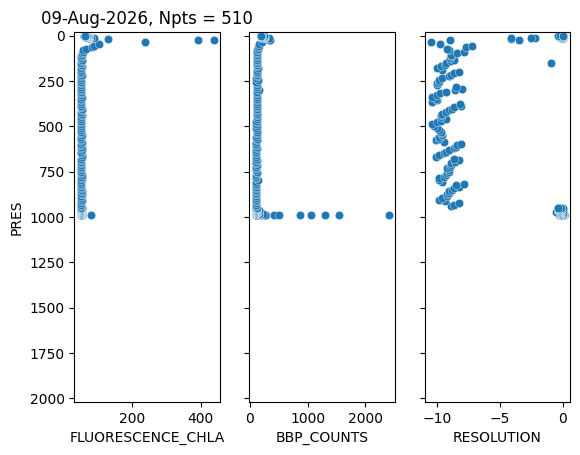

#08#
[PARK]
2026-08-10 00:44:17,976.10,51,110
2026-08-10 01:44:24,989.20,50,111
2026-08-10 02:44:26,992.30,52,109
2026-08-10 03:44:28,987.90,50,110
2026-08-10 04:44:30,994.30,51,110
2026-08-10 05:44:31,983.00,52,110
2026-08-10 06:44:33,989.70,51,110
2026-08-10 07:44:35,986.50,51,109
2026-08-10 08:44:37,999.80,51,110
2026-08-10 09:44:39,987.90,52,113
2026-08-10 10:44:41,991.00,51,111
2026-08-10 11:44:43,987.10,53,112
2026-08-10 12:44:45,993.30,52,111
2026-08-10 13:44:47,987.50,52,109
2026-08-10 14:44:49,997.30,51,111
2026-08-10 15:44:51,977.30,51,112
2026-08-10 16:44:53,989.40,52,110
2026-08-10 17:44:55,990.10,51,109
2026-08-10 18:44:57,996.40,52,108
2026-08-10 19:44:59,991.30,50,113
2026-08-10 20:45:01,990.60,51,110
2026-08-10 21:45:03,993.70,51,109
2026-08-10 22:45:04,992.40,51,110
2026-08-10 23:45:06,992.90,51,113
2026-08-11 00:45:08,989.90,50,110
2026-08-11 01:45:07,990.90,52,146
2026-08-11 02:45:09,991.70,50,113
2026-08-11 03:45:11,990.50,52,113
2026-08-11 04:45:13,996.40,52,110
20

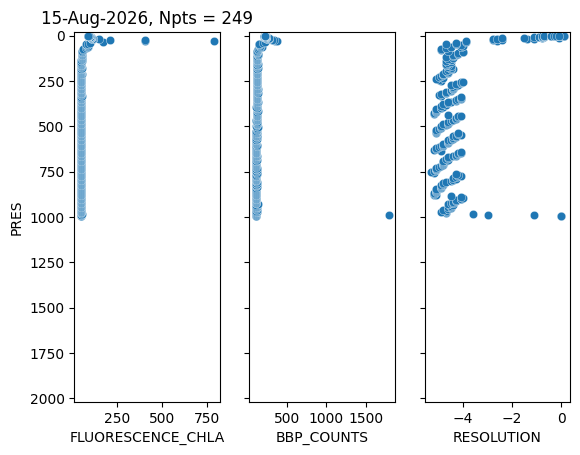

#08#
[PARK]
2026-08-16 00:21:53,972.80,50,109
2026-08-16 01:22:04,1028.60,52,106
2026-08-16 02:22:09,1028.20,53,111
2026-08-16 03:22:12,1033.00,52,109
2026-08-16 04:22:15,1030.40,51,110
2026-08-16 05:22:18,1032.60,51,109
2026-08-16 06:22:21,1033.10,51,108
2026-08-16 07:22:24,1032.70,51,111
2026-08-16 08:22:27,1028.60,53,112
2026-08-16 09:22:30,1031.60,52,108
2026-08-16 10:22:33,1030.40,52,109
2026-08-16 11:22:36,1030.80,52,112
2026-08-16 12:22:39,1034.80,51,110
2026-08-16 13:22:42,1030.40,50,109
2026-08-16 14:22:45,1034.30,51,109
2026-08-16 15:22:48,1028.20,51,218
2026-08-16 16:22:51,1037.40,50,108
2026-08-16 17:22:54,1031.70,53,111
2026-08-16 18:22:57,1023.90,51,109
2026-08-16 19:23:00,1038.60,51,108
2026-08-16 20:23:03,1036.20,52,109
2026-08-16 21:23:06,1033.60,51,114
2026-08-16 22:23:09,1032.80,51,108
2026-08-16 23:23:12,1034.00,51,109
2026-08-17 00:23:15,1030.40,51,111
2026-08-17 01:23:14,1032.80,51,111
2026-08-17 02:23:16,1032.20,51,114
2026-08-17 03:23:19,1036.30,51,108
2026-08-1

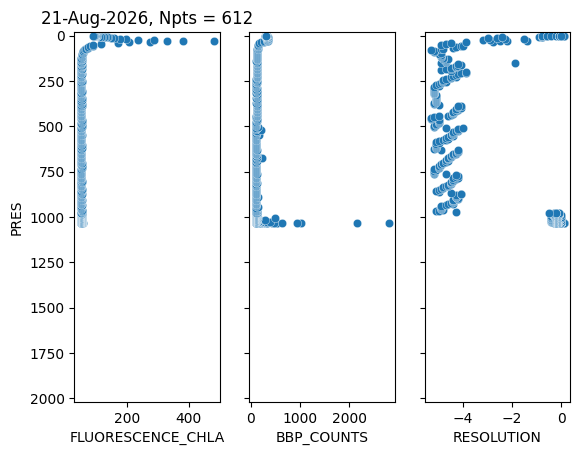

#08#
[PARK]
2026-08-22 06:49:01,1971.10,51,108
2026-08-22 07:49:07,1979.10,50,104
2026-08-22 08:49:10,1978.30,52,107
2026-08-22 09:49:13,1981.40,51,107
2026-08-22 10:49:15,1972.40,52,104
2026-08-22 11:49:18,1980.20,51,104
2026-08-22 12:49:21,1983.00,50,106
2026-08-22 13:49:24,1981.40,52,106
2026-08-22 14:49:27,1981.20,51,107
2026-08-22 15:49:30,1983.10,52,107
2026-08-22 16:49:33,1985.10,51,107
2026-08-22 17:49:36,1984.00,52,114
2026-08-22 18:49:38,1982.10,52,106
2026-08-22 19:49:41,1981.00,50,110
2026-08-22 20:49:44,1986.60,51,107
2026-08-22 21:49:47,1981.90,52,106
2026-08-22 22:49:50,1980.40,51,106
2026-08-22 23:49:53,1982.70,51,105
2026-08-23 00:49:56,1986.40,52,108
2026-08-23 01:49:59,1984.00,51,107
2026-08-23 02:50:02,1985.80,52,107
2026-08-23 03:50:05,1978.70,52,106
2026-08-23 04:50:07,1983.60,50,107
2026-08-23 05:50:10,1982.40,51,107
2026-08-23 06:50:13,1992.90,52,108
2026-08-23 07:50:13,1982.00,50,108
2026-08-23 08:50:16,1986.50,52,107
2026-08-23 09:50:19,1984.90,51,134
2026-08-

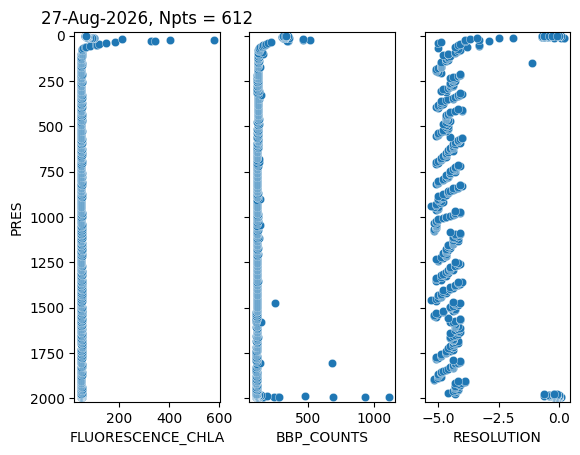

In [114]:
eco_files = list(Path('../data/provor/300125062035430/').glob('*eco*.csv'))

for fn in eco_files[-4:]:
        fig, axes = plt.subplots(1, 3, sharey=True)
        data = read_eco(fn)
        data = data.loc[data['SAMPLE'] == 'ASCENT']
        data['RESOLUTION'] = data.PRES.diff()
        sns.scatterplot(data=data, x='FLUORESCENCE_CHLA', y='PRES', linewidth=0.25, ax=axes[0])
        sns.scatterplot(data=data, x='BBP_COUNTS', y='PRES', linewidth=0.25, ax=axes[1])
        sns.scatterplot(data=data, x='RESOLUTION', y='PRES', linewidth=0.25, ax=axes[2])
        axes[0].set_ylim((2020, -20))
        axes[0].set_title(f'{data["TIME"].iloc[0].strftime("%d-%b-%Y")}, Npts = {data.shape[0]}')
        plt.show()


[WindowsPath('../data/provor/300125062035430/59e4_156_01_eco.csv'),
 WindowsPath('../data/provor/300125062035430/59e4_157_01_eco.csv'),
 WindowsPath('../data/provor/300125062035430/59e4_158_01_eco.csv'),
 WindowsPath('../data/provor/300125062035430/59e4_159_01_eco.csv'),
 WindowsPath('../data/provor/300125062035430/59e4_160_01_eco.csv'),
 WindowsPath('../data/provor/300125062035430/59e4_161_01_eco.csv'),
 WindowsPath('../data/provor/300125062035430/59e4_162_01_eco.csv'),
 WindowsPath('../data/provor/300125062035430/59e4_163_01_eco.csv')]